# Retail Demand Forecasting & Inventory Optimization

Retailers often face challenges in predicting product demand, leading to stockouts or overstock, which results in lost revenue or increased costs.

This project aims to forecast daily product demand for a retail store, simulate inventory requirements, and optimize stock levels.

Using historical sales transactions, pricing, promotions, and seasonal trends, the project will provide actionable insights for business decisions and will be presented through interactive dashboards.

The dataset contains transaction-level sales data, including: **Transaction ID**, **Customer ID**, **Category**, **Item**, **Price Per Unit**, **Quantity**, **Location**, **Transaction Date**. We have also added necessary columns for the project objective: **Season**, **Month**, **Weekday**, **Stock_On_Hand**, **Promotion**, and recalculated **Revenue**.

# Data Cleaning Notebook Objectives

The purpose of this notebook is to:

- Ensure the dataset is clean, consistent, and complete.

- Handle missing values, duplicates, and anomalies.

- Confirm that all columns required for forecasting and inventory optimization are present and correctly populated.

- Save a cleaned dataset ready for exploratory data analysis (EDA) and feature engineering.

## Importing Libraries

In [ ]:
import pandas as pd #importing pandas for data cleaning
import numpy as np #importing numpy for mathematical calculations
import matplotlib.pyplot as plt #importing matplotlib for graphs
import seaborn as sns #importing seaborn for graphs

## Loading the dataset
This step helps us understand the structure, data types, and basic statistics of the dataset.

In [ ]:
df= pd.read_csv('BrightMart_retail_dataset.csv') #loading the dataset
df.head()  #displaying first five rows of the dataset

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Payment Method,Location,Transaction Date,Discount Applied,Season,Month,Weekday,Stock_On_Hand,Promotion,Revenue
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,Digital Wallet,Online,2024-04-08,True,Spring,April,Monday,152,10,166.50
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,Digital Wallet,Online,2023-07-23,True,Summer,July,Sunday,142,10,234.90
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,Credit Card,Online,2022-10-05,False,Fall,October,Wednesday,64,10,38.70
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,Credit Card,Online,2022-05-07,NaN,Spring,May,Saturday,156,10,222.75
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,Digital Wallet,Online,2022-10-02,False,Fall,October,Sunday,121,0,87.50


In [ ]:
df.info() #displaying dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Payment Method    12575 non-null  object 
 7   Location          12575 non-null  object 
 8   Transaction Date  12575 non-null  object 
 9   Discount Applied  8376 non-null   object 
 10  Season            12575 non-null  object 
 11  Month             12575 non-null  object 
 12  Weekday           12575 non-null  object 
 13  Stock_On_Hand     12575 non-null  int64  
 14  Promotion         12575 non-null  int64  
 15  Revenue           11362 non-null  float64
dtypes: float64(3), int64(2), object(11)
memo

In [ ]:
df.describe() #displaying statistical summary of the dataset

,Price Per Unit,Quantity,Stock_On_Hand,Promotion,Revenue
count,11966.000000,11971.000000,12575.000000,12575.000000,11362.000000
mean,23.365912,5.536380,124.549026,3.965010,124.545890
std,10.743519,2.857883,43.209408,6.631143,91.620313
min,5.000000,1.000000,50.000000,0.000000,4.000000
25%,14.000000,3.000000,87.000000,0.000000,49.500000
50%,23.000000,6.000000,125.000000,0.000000,100.800000
75%,33.500000,8.000000,162.000000,10.000000,182.500000
max,41.000000,10.000000,199.000000,20.000000,410.000000


###Initial Dataset Check
- Dataset has 12,575 rows and 16 columns
- Missing values exist in Item (1213), Price Per Unit (609), Quantity (604), Discount Applied (4199), Revenue (1213)
- No duplicated rows
- Revenue and Quantity have potential outliers

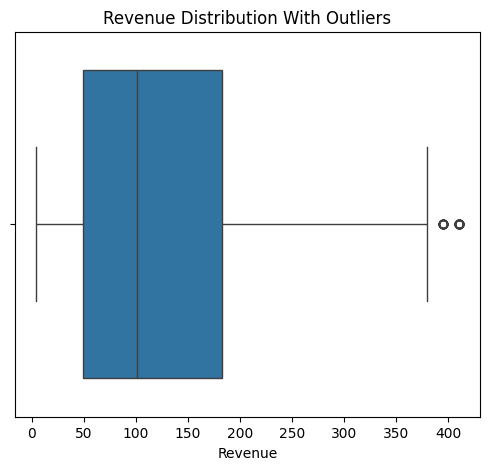

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Distribution With Outliers")
plt.show()

#### There are Outliers in the Revenue column because  
- some transactions have very high revenue, which appear as outliers.
- Some customers purchase large quantities, which increases the transaction value.
- Removing these “outliers” would distort the real business scenario, since in retail, extreme sales are valid and important for forecasting and inventory decisions.

## Check for Missing Values and Duplicates
Identifies missing or duplicate entries that need cleaning.

In [ ]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:
 Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
Season                 0
Month                  0
Weekday                0
Stock_On_Hand          0
Promotion              0
Revenue             1213
dtype: int64
Number of duplicate rows: 0


##Handling Missing Values

In [ ]:
# Item Column is a categorical column, so we are filling it with 'Unknown'
df['Item'] = df['Item'].fillna('Unknown')

In [ ]:
# Price Per Unit and Quantity
# Fill Price Per Unit by the mean price of that category
df['Price Per Unit']= df.groupby('Category')['Price Per Unit'].transform(lambda x: x.fillna(x.mean()))
# Fill Quantity by median of that category (here mean is 5.54 and median is 6, so it is left-skewed, median is better in this case.)
df['Quantity']= df.groupby('Category')["Quantity"].transform(lambda x:x.fillna(x.median()))

In [ ]:
# Revenue
# Recalculate based on updated Price and Quantity and Promotion
df['Revenue']= df['Quantity']*df['Price Per Unit']*(1-df['Promotion']/100)

In [ ]:
# Discount Applied
# If Promotion > 0 → True, else False
df["Discount Applied"]= df['Promotion'].apply(lambda x: True if x > 0 else False)

###We have handled all missing values logically based on business understanding.

## Verify & Clean Column Names

In [ ]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Standardize column names to Title Case
df.columns = [col.title().replace("_", " ") for col in df.columns]#Removes extra spaces from column names and makes them consistent for presentation)

###Trim Spaces in Object Columns

In [ ]:
# Strip spaces from all object columns
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].str.strip()

# Standardize text formatting (first letter capital, rest small)
for col in object_cols:
    df[col] = df[col].str.title()

###Column names and categorical values are now consistent and presentation-ready.

In [ ]:
# Remove unnecessary columns if needed
columns_to_drop = ['Transaction Id', 'Customer Id']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# changing datatype of'Transaction Date' in datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Check data types
df.dtypes

,0
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Payment Method,object
Location,object
Transaction Date,datetime64[ns]
Discount Applied,bool
Season,object
Month,object


### Corrected Dataset
- Transaction ID and Customer ID are unique identifiers, not needed for analysis.
- Transaction Date converted to datetime for proper time-based analysis.
- All other datatypes are now correct.

In [ ]:
df.head()

,Category,Item,Price Per Unit,Quantity,Payment Method,Location,Transaction Date,Discount Applied,Season,Month,Weekday,Stock On Hand,Promotion,Revenue
0,Patisserie,Item_10_Pat,18.5,10.0,Digital Wallet,Online,2024-04-08,True,Spring,April,Monday,152,10,166.50
1,Milk Products,Item_17_Milk,29.0,9.0,Digital Wallet,Online,2023-07-23,True,Summer,July,Sunday,142,10,234.90
2,Butchers,Item_12_But,21.5,2.0,Credit Card,Online,2022-10-05,True,Fall,October,Wednesday,64,10,38.70
3,Beverages,Item_16_Bev,27.5,9.0,Credit Card,Online,2022-05-07,True,Spring,May,Saturday,156,10,222.75
4,Food,Item_6_Food,12.5,7.0,Digital Wallet,Online,2022-10-02,False,Fall,October,Sunday,121,0,87.50


In [ ]:
# Check for remaining missing values
df.isnull().sum()

,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Payment Method,0
Location,0
Transaction Date,0
Discount Applied,0
Season,0
Month,0


In [ ]:
# Verify dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Category          12575 non-null  object        
 1   Item              12575 non-null  object        
 2   Price Per Unit    12575 non-null  float64       
 3   Quantity          12575 non-null  float64       
 4   Payment Method    12575 non-null  object        
 5   Location          12575 non-null  object        
 6   Transaction Date  12575 non-null  datetime64[ns]
 7   Discount Applied  12575 non-null  bool          
 8   Season            12575 non-null  object        
 9   Month             12575 non-null  object        
 10  Weekday           12575 non-null  object        
 11  Stock On Hand     12575 non-null  int64         
 12  Promotion         12575 non-null  int64         
 13  Revenue           12575 non-null  float64       
dtypes: bool(1), datetime64

##Summary of Cleaning Steps:
- Filled missing categorical values (Item) with 'Unknown'.
- Filled Price Per Unit with mean of category.
- Filled Quantity with median of category (robust to skewed data).
- Recalculated Revenue based on updated Price, Quantity, and Promotion.
- Updated Discount Applied based on Promotion > 0.
- Cleaned column names and standardized text formatting.
- Dropped unnecessary identifier columns (Transaction ID, Customer ID).
- Converted Transaction Date to datetime.
- Analyzed Revenue outliers; kept them as they reflect realistic business scenarios.

## Saving the Cleaned dataset for EDA

In [ ]:
df.to_csv('cleaned_BrightMart_retail_dataset.csv', index=False)
print("Cleaned dataset saved")

Cleaned dataset saved
